In [2]:
# imports

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import itertools
from matplotlib.cm import viridis
from matplotlib.cm import cool
from matplotlib.colors import Normalize
import copy
import random

In [3]:
# ============================
# Bismuth parameters (given)
# ============================
bi_mass = 208.9804
energy_in_ev = 0.004180159285619251
freq_in_thz = 6.3507799295888985
t_in_ps = 1.0 / freq_in_thz

# Network configuration variables
input_size = 1
hidden_size = 5
output_size = 1

#Time array parameters
steps = 20000
total_time=20/t_in_ps
tspan = [0, total_time]
tfine = np.linspace(*tspan, steps)
t_eval = tfine

num_peaks = 5      # Number of Gaussian peaks
std_dev = (0.03 / t_in_ps)      # Standard deviation of the Gaussian peaks

In [4]:
import numpy as np
from pathlib import Path
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import minimize_scalar, root_scalar

# ============================
# Load PES (eV) on raw x-grid (Å)
# ============================
pes_path = Path("Input_files/toten.dat")
energies_ev = np.loadtxt(pes_path)
x_raw = np.linspace(-0.5, 0.9, len(energies_ev))

# Build spline in INTERNAL energy units
U_raw = InterpolatedUnivariateSpline(x_raw, energies_ev / energy_in_ev, k=5)

# ============================
# 1) Find saddle in RAW coords robustly via U'(x)=0 (higher precision)
# ============================
saddle_bracket_raw = (0.05, 0.45)  # adjust only if your PES changes drastically

res_s = root_scalar(
    lambda xx: float(U_raw(xx, nu=1)),
    bracket=saddle_bracket_raw,
    method="brentq",
    xtol=1e-14,
    rtol=1e-12,
    maxiter=200
)
x_saddle_raw = float(res_s.root)

Upp_s = float(U_raw(x_saddle_raw, nu=2))
if Upp_s >= 0:
    print("[WARN] U''(saddle) >= 0; saddle_bracket_raw may not bracket the barrier maximum.")
    
# ============================
# 2) Shift x so saddle is exactly at 0, rebuild shifted spline
# ============================
x_shifted = x_raw - x_saddle_raw
#x=x_shifted
U = InterpolatedUnivariateSpline(x_shifted, energies_ev / energy_in_ev, k=5)

# By definition in shifted coords:
bi_xmax = 0.0  # saddle position EXACT

# ============================
# 3) Find left minimum in shifted coords (negative)
# ============================
xmin_bracket = (-0.6, -0.02)  # should cover left well region
res_min = minimize_scalar(
    lambda xx: float(U(xx, nu=0)),
    bounds=xmin_bracket,
    method="bounded",
    options={"xatol": 1e-14, "maxiter": 1000}
)
bi_xmin = float(res_min.x)

# ============================
# 4) Harmonic frequency at minimum
# ============================
bi_phomega = np.sqrt(float(U(bi_xmin, nu=2)) / bi_mass)
bi_phfreq_in_thz = bi_phomega * freq_in_thz / (2.0 * np.pi)

# Useful derived scale: distance from saddle to minimum
x_scale = abs(bi_xmin)

# ============================
# Diagnostics
# ============================
print("n_points =", len(x_raw))
print("x_saddle (raw Å)      =", x_saddle_raw)
print("saddle at shifted x   =", bi_xmax)
print("bi_xmin (shifted Å)   =", bi_xmin)
print("x_scale=|xmin| (Å)    =", x_scale)
print("bi_phfreq_in_thz      =", bi_phfreq_in_thz)


n_points = 105
x_saddle (raw Å)      = 0.23589478616538526
saddle at shifted x   = 0.0
bi_xmin (shifted Å)   = -0.23686869232657531
x_scale=|xmin| (Å)    = 0.23686869232657531
bi_phfreq_in_thz      = 3.0337851510905756


max_Rx: 120.32411353355155, R_xmin: 82.78838923786834


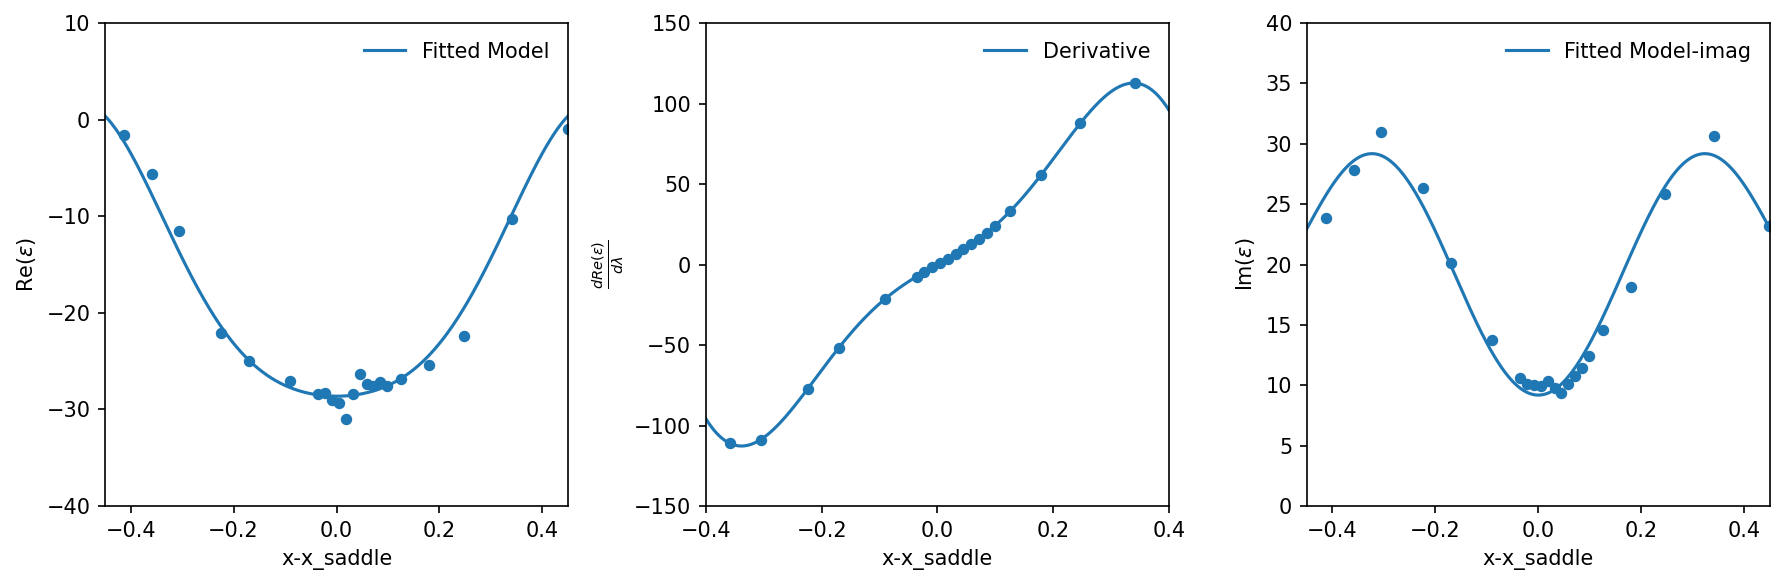

In [5]:
from numpy.linalg import lstsq

file_path = '/Users/sagrawal/Box/Research/ANL-Research/Carbon-data/Bi/single-point/finer-grid/analysis-plot-dielec/out-data'
baseDirs = [f"{file_path}/ismear_-5", f"{file_path}/ismear_-5_morek_moreband"] 
all_pos2 = [4, 12, 16, 24, 28, 32, 38, 42, 48, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 68, 73, 80, 88, 96]

#------------- CHI -------------------------------------------------------------------
for idx, baseDir in enumerate(baseDirs, start=1):
    bi_ = []
    
    for i in all_pos2:
        filename = f"{baseDir}/chi_{i}.dat" 
        data = np.loadtxt(filename, delimiter=" ") 
        
        for row in data:
            if 1.90 <= row[0] <= 2.05:
                bi_.append(row[1] + 1j * row[2])
                #print(f"i, bi_eps = {i, row[1]}")
    
    globals()[f'bi_eps_2eV_chi_{idx}'] = bi_
 
bi_eps_2eV_chi_2 = np.array(bi_eps_2eV_chi_2)  

xcoarse = x_shifted[all_pos2]
xfine = np.linspace(-0.5, 0.9, 1000)
xfine=xfine-x_saddle_raw

x = xcoarse
y = bi_eps_2eV_chi_2.real
y_im = bi_eps_2eV_chi_2.imag

num = 9
X_poly = np.column_stack([np.ones_like(x)] + [x**i for i in range(2, num, 2)])

# Fit a regression model: solve the normal equations for least squares
coefficients, residuals, rank, s = lstsq(X_poly, y, rcond=None)

poly_model = lambda x: sum([coefficients[i] * x**(2 * i) for i in range(len(coefficients))])

poly_derivative_func = lambda x: sum([(2 * i) * coefficients[i] * x**(2 * i - 1) for i in range(1, len(coefficients))])

y_fitted = poly_model(xfine)

y_der_xcoarse = poly_derivative_func(x)
y_derivative = poly_derivative_func(xfine)
max_value = np.max(y_derivative)
R_xmin = poly_derivative_func(x_saddle_raw)

print(f"max_Rx: {max_value}, R_xmin: {R_xmin}")

#---------------- Imaginary part --------------------------------------
coefficients_im, residuals_im, rank_im, s_im = lstsq(X_poly, y_im, rcond=None)

poly_model_im = lambda x: sum([coefficients_im[i] * x**(2 * i) for i in range(len(coefficients_im))])

poly_derivative_func_im = lambda x: sum([(2 * i) * coefficients_im[i] * x**(2 * i - 1) for i in range(1, len(coefficients_im))])

y_fitted_im = poly_model_im(xfine)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=150, facecolor='white')

ax[0].scatter(x, y, color='C0', s=20, label='')
ax[0].plot(xfine, y_fitted, label='Fitted Model')

ax[1].scatter(x, y_der_xcoarse, s=20, color='C0', label='')
ax[1].plot(xfine, y_derivative, label='Derivative')

ax[2].scatter(x, y_im, color='C0', s=20, label='')
ax[2].plot(xfine, y_fitted_im, label='Fitted Model-imag')

ax[0].legend(frameon=False)
ax[0].set_xlim(-0.45, 0.45)
ax[0].set_ylim(-40, 10)
ax[0].set_xlabel("x-x_saddle")
ax[0].set_ylabel('Re($\epsilon$)')

ax[1].legend(frameon=False)
ax[1].set_xlim(-0.4, 0.4)
ax[1].set_ylim(-150, 150)
ax[1].set_xlabel("x-x_saddle")
ax[1].set_ylabel(r'$\frac{d Re(\epsilon)}{d \lambda}$')

ax[2].legend(frameon=False)
ax[2].set_xlim(-0.45, 0.45)
ax[2].set_ylim(0, 40)
ax[2].set_xlabel("x-x_saddle")
ax[2].set_ylabel('Im($\epsilon$)')

fig.tight_layout()

In [6]:
a=2*np.pi*(1/19.5)/freq_in_thz
b=2*np.pi*(1/0.3)/freq_in_thz

print(a,b)

const_b1 = 0
const_w2 = 10

class TestFNN_ex2(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, w1_array):
        super(TestFNN_ex2, self).__init__()
        # Simple feed-forward with one hidden layer
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.fc2 = nn.Linear(hidden_size, output_size)
        #self.init_weights()
    
    #def init_weights(self):
        # Initialize weights and biases with Gaussian distribution (mean=0, std=1) 
        self.fc1.weight.data = torch.FloatTensor(w1_array).view(hidden_size, input_size)  # Ensure the correct shape
        nn.init.constant_(self.fc1.bias, const_b1)
        nn.init.constant_(self.fc2.weight, const_w2)
        nn.init.constant_(self.fc2.bias, 0)
    
    def forward(self, x):
        x = torch.sin(self.fc1(x))  # Using sinusoidal activation function
        x = self.fc2(x)
        return x
        
    def get_output(self, time):
        """Get neural network output for a given time input."""
        time_tensor = torch.tensor([[time]], dtype=torch.float32)
        with torch.no_grad():
            return self(time_tensor).item()

            
# def mutate(network, mutation_strength=0.2):
#     """ Mutates the network by adding Gaussian noise to its weights and biases. """
#     with torch.no_grad():
#         for name, param in network.named_parameters():
#             if name == 'fc1.weight':
#                 # Generate noise with the same shape as the parameter
#                 noise = torch.randn_like(param) * mutation_strength
#                 # Apply noise in-place
#                 param.add_(noise)
#                 param.clamp_(min=a, max=b)

def mutate(network, mutation_strength=0.2, min_sep_ps=0.2, max_tries=200):
    """
    Mutate fc1.weight until the resulting pulse times have
    minimum spacing >= min_sep_ps.
    """
    with torch.no_grad():
        for name, param in network.named_parameters():
            if name == 'fc1.weight':
                # keep original weights in case retries fail
                w_old = param.detach().clone()

                accepted = False

                for attempt in range(max_tries):
                    # start from original each time
                    w_trial = w_old.clone()

                    # mutate
                    noise = torch.randn_like(w_trial) * mutation_strength
                    w_trial.add_(noise)
                    w_trial.clamp_(min=a, max=b)

                    # convert to pulse times in ps
                    w_np = w_trial.detach().cpu().numpy().reshape(-1)
                    times_ps = 2 * np.pi / (freq_in_thz * w_np)

                    # check minimum spacing
                    times_sorted = np.sort(times_ps)
                    min_gap = np.min(np.diff(times_sorted))

                    if min_gap >= min_sep_ps:
                        param.copy_(w_trial)
                        accepted = True
                        # optional debug
                        #print(f"Accepted after {attempt+1} tries; min gap = {min_gap:.3f} ps")
                        break

                if not accepted:
                    # fallback: keep old weights unchanged
                    param.copy_(w_old)
                    # optional debug
                    print(f"Mutation rejected after {max_tries} tries; keeping old weights.")

0.050736229992191274 3.297854949492433


In [7]:
def init_pop(size, input_size, hidden_size, output_size, dt=1/bi_phfreq_in_thz):
    population = []
    fc1_wt = []  # List to store the fc1 weights separately
    
    # Generate a list of weights arrays with proper starting value
    for i in range(size):
        increment =   0.13*dt * (i + 9)  # Increment increases with each population
        times_array = np.array([dt + (j) * increment for j in range(hidden_size)])
        weights_array = 2*np.pi*(1/times_array)/freq_in_thz
        weights_tensor = torch.tensor(weights_array, dtype=torch.float).view(hidden_size, input_size)
        # if i==0 or i==size-1 or i==size-2:
        #     print("times_array, weights_array = ",times_array, "\n", weights_array)
        model = TestFNN_ex2(input_size, hidden_size, output_size, weights_array)
        population.append(model)
        fc1_wt.append(weights_tensor)  # Store the numpy array directly

    return population, fc1_wt

n_pop=70
# Initialize population
pop, pop_fc1_wt = init_pop(n_pop, input_size, hidden_size, output_size, dt=1/bi_phfreq_in_thz)

# Simulation time data
time_steps = torch.linspace(*tspan, steps).reshape(-1, 1)  # Simulating over a time span

(0.0, 5.0)

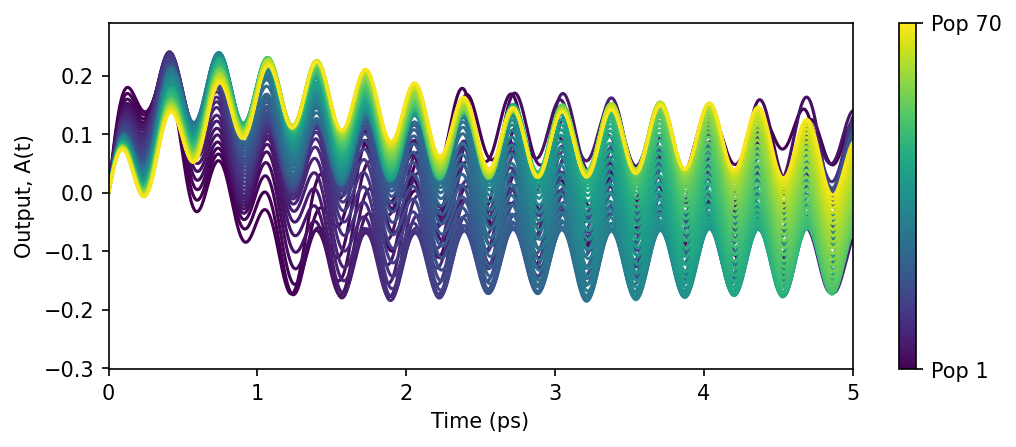

In [8]:
# Plotting the data
from scipy.integrate import simpson

fig, ax = plt.subplots(figsize=(8, 3), dpi=150, facecolor='white')
norm = Normalize(vmin=1, vmax=n_pop)
sm = plt.cm.ScalarMappable(cmap=viridis, norm=norm)
sm.set_array([])

# Plot each network's output using a color from the viridis colormap
for i, net in enumerate(pop):
    with torch.no_grad():
        A_t = net(time_steps)
        A_t_squared = A_t.squeeze() ** 2  
        A_t_squared_np = A_t_squared.numpy()

        # Perform numerical integration of A(t)^2 over the time domain
        integral_A_t_squared = simpson(A_t_squared_np, x=time_steps.numpy().squeeze())  
        A_t_norm=A_t.numpy()/np.sqrt(integral_A_t_squared)
        
    ax.plot(tfine*t_in_ps, A_t_norm, label=f'Pop {i+1}', color=viridis(norm(i)))
    #ax.plot(tfine*t_in_ps, A_t, label=f'Pop {i+1}', color=viridis(norm(i)))
    
# Add colorbar
cbar = plt.colorbar(sm, ax=ax, ticks=range(n_pop))
cbar.set_ticks([norm.vmin, norm.vmax])
cbar.ax.set_yticklabels(['Pop 1', f'Pop {n_pop}'])  

ax.set_xlabel('Time (ps)')
ax.set_ylabel('Output, A(t)')
ax.set_xlim(0,5)
#plt.savefig("sine_func-5.png")


integral of normalized signal =  1.0


[Text(1, 1.0, 'Pop 1'), Text(1, 70.0, 'Pop 70')]

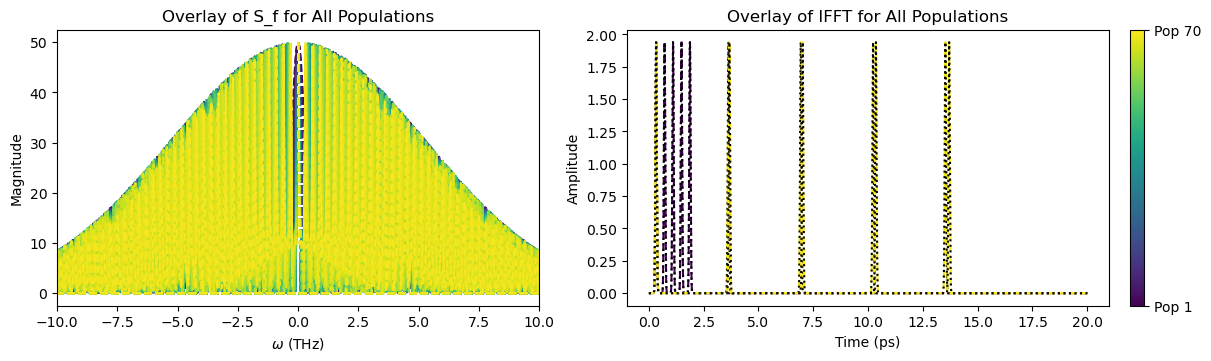

In [9]:
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
from scipy.interpolate import PchipInterpolator

w1 = pop_fc1_wt
b1 = np.full(hidden_size, const_b1)
w2 = np.full(hidden_size, const_w2)
sigma=0.03/t_in_ps
t=tfine

fft_freqs = np.fft.fftfreq(len(tfine), d=(tfine[1] - tfine[0])*t_in_ps)
G_f = np.exp(-2 * np.pi**2 * sigma**2 * fft_freqs**2 * t_in_ps**2) 

def theor_fft(w1, b1, w2):
    results = []
    for weights in w1:
        weights = np.array(weights, dtype=np.float32)
        M_f_nn = np.sum(
            [w2[n] * np.exp(-1j * 2 * np.pi * fft_freqs * ((2 * np.pi / (freq_in_thz * weights[n])) + b1[n]))
             for n in range(len(weights))], axis=0
        )
        S_f_nn = G_f * M_f_nn
        ifft_nn = np.fft.ifft(S_f_nn)
        results.append((S_f_nn, ifft_nn))
    return results

# Run the function for the population of weights
results = theor_fft(pop_fc1_wt, b1, w2)
t_finer = np.linspace(*tspan, 30000)

cmap = cm.viridis  
norm = plt.Normalize(1, n_pop, 256)  

# Create the figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)
colors = [cmap(norm(num)) for num in range(n_pop)]

# Plot for S_f
for idx, (S_f, ifft) in enumerate(results):
    axs[0].plot(fft_freqs, np.abs(S_f), linestyle='--', color=colors[idx])
axs[0].set_title('Overlay of S_f for All Populations')
axs[0].set_xlabel('$\omega$ (THz)')
axs[0].set_ylabel('Magnitude')
axs[0].set_xlim(-10, 10)

# Plot for IFFT
selected = [(0, results[0]),(n_pop - 2, results[n_pop - 2]), (n_pop - 1, results[n_pop - 1])]

for idx, (S_f, ifft) in selected:
#for idx, (S_f, ifft) in enumerate(results):
    
    # Step 2: Calculate the integral of the IFFT result and normalize
    integral_ifft = simpson(ifft.real**2, x=t*t_in_ps)
    norm_ifft = ifft.real / np.sqrt((integral_ifft))
    ifft_interpolator = CubicSpline(t*t_in_ps, ifft.real)
    ifft_interpolated = ifft_interpolator(t_finer*t_in_ps)

    axs[1].plot(t*t_in_ps, norm_ifft.real, linestyle='--', color=colors[idx])
    axs[1].plot(t_finer*t_in_ps, ifft_interpolated.real/np.sqrt(integral_ifft), 'k:', label='Cubic Interpolated IFFT')
axs[1].set_title('Overlay of IFFT for All Populations')
axs[1].set_xlabel('Time (ps)')
axs[1].set_ylabel('Amplitude')

int_norm = simpson(norm_ifft.real**2, x=t*t_in_ps)
print("integral of normalized signal = ", int_norm)

# Color bar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_ticks([norm.vmin, norm.vmax])
cbar.ax.set_yticklabels(['Pop 1', f'Pop {n_pop}'])  # 'Pop 1' and 'Pop n_pop'

In [10]:
x_scale = np.abs(bi_xmin)
x_saddle = x_scale

def score3(all_v, all_x, debug=False):
    """
    Score based on average x over full oscillation windows (between v=0 crossings)

    Returns:
        scores      : list of floats
        tindex      : list of times (ps)
        bad_indices : list of trajectory indices where scoring failed
    """

    scores = []
    tindex = []
    bad_indices = []

    for k, (result, x_values) in enumerate(zip(all_v, all_x)):

        indices = []
        time_v0 = []
        time_x0 = []

        # ------------------ v = 0 crossings ------------------
        for i in range(1, len(result)):
            if (result[i] * result[i - 1]) < 0:
                indices.append(i - 1)
                time_v0.append(tfine[i - 1] * t_in_ps)

        # ------------------ x = ±x_saddle crossings ------------------
        for i in range(1, len(indices)):
            i_start = indices[i - 1]
            i_end   = indices[i]

            min_x = np.min(x_values[i_start:i_end])

            # avoid j-1 bug
            j_start = max(1, i_start)

            if min_x < 0:
                for j in range(j_start, i_end):
                    if ((x_values[j - 1] < -x_saddle and x_values[j] > -x_saddle) or
                        (x_values[j - 1] > -x_saddle and x_values[j] < -x_saddle)):
                        time_x0.append(tfine[j - 1] * t_in_ps)

            elif min_x > 0:
                for j in range(j_start, i_end):
                    if ((x_values[j - 1] < x_saddle and x_values[j] > x_saddle) or
                        (x_values[j - 1] > x_saddle and x_values[j] < x_saddle)):
                        time_x0.append(tfine[j - 1] * t_in_ps)

        # ------------------ window averaging ------------------
        avg_pos = []
        traj_avg = []
        windows = []

        # need at least 3 crossings to define a window
        for i in range(1, len(indices) - 2, 2):

            start_index = indices[i]
            end_index   = indices[i + 2]

            if end_index >= len(x_values):
                continue

            windows.append((start_index, end_index))

            segment = x_values[start_index:end_index + 1]

            if len(segment) > 0:
                avg_pos.append(np.mean(segment))
            else:
                avg_pos.append(0.0)

        # ------------------ convert to score ------------------
        for val in avg_pos:
            if val <= 0:
                frac = 1 + (val / x_saddle)
            else:
                frac = 1 - (val / x_saddle)
            traj_avg.append(frac)

        # ------------------ handle bad trajectories ------------------
        if len(traj_avg) == 0:

            bad_indices.append(k)

            if debug:
                print(f"\nDEBUG: bad trajectory {k}")
                print("  len(indices) =", len(indices))
                print("  len(time_v0) =", len(time_v0))
                print("  x range =", np.min(x_values), np.max(x_values))
                print("  v range =", np.min(result), np.max(result))

            scores.append(0.0)
            tindex.append(0.0)
            continue

        # ------------------ best window ------------------
        max_value = max(traj_avg)
        max_index = traj_avg.index(max_value)

        max_window_end_index = windows[max_index][1]

        # safer than old indexing
        max_time = tfine[max_window_end_index] * t_in_ps

        scores.append(max_value)
        tindex.append(max_time)

    return scores, tindex, bad_indices

In [11]:
# ============================================================
# CELL 1 — physics + propagate + simulate
# CLEAN DIMENSIONLESS-n VERSION WITH EXPLICIT PULSE AREA SCALE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp, simpson
from scipy.interpolate import CubicSpline
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter

from scipy.constants import hbar, elementary_charge, atomic_mass

# ============================================================
# 0. INTERNAL-UNIT SYSTEM
#    Base units:
#       hbar = 1
#       e    = 1
#       amu  = 1
#       length = 1 Angstrom
# ============================================================

LENGTH_UNIT_M = 1.0e-10
MASS_UNIT_KG  = atomic_mass

ENERGY_UNIT_J  = hbar**2 / (MASS_UNIT_KG * LENGTH_UNIT_M**2)
ENERGY_UNIT_EV = ENERGY_UNIT_J / elementary_charge
TIME_UNIT_S    = hbar / ENERGY_UNIT_J
TIME_UNIT_PS   = TIME_UNIT_S / 1.0e-12
EFIELD_UNIT_V_PER_M = ENERGY_UNIT_J / (elementary_charge * LENGTH_UNIT_M)
EFIELD_UNIT_MV_PER_M = EFIELD_UNIT_V_PER_M / 1.0e6

print("=== Internal unit system ===")
print(f"ENERGY_UNIT_EV        = {ENERGY_UNIT_EV:.8e} eV")
print(f"TIME_UNIT_PS          = {TIME_UNIT_PS:.8e} ps")
print(f"EFIELD_UNIT_V_PER_M   = {EFIELD_UNIT_V_PER_M:.8e} V/m")
print(f"EFIELD_UNIT_MV_PER_M  = {EFIELD_UNIT_MV_PER_M:.8e} MV/m")

# ============================================================
# 1. Default c2 in internal units
# ============================================================

c2_eV_per_A2 = 0.41 / (0.378**2)
c2_int_default = c2_eV_per_A2 / ENERGY_UNIT_EV

beta_paper = 10.3   # ps

# ============================================================
# 2. Cell volume from lattice vectors
# ============================================================

LATTICE_VECTORS_A = np.array([
    [4.7459001541, 0.0,          0.0],
    [2.5683164347, 3.9909045296, 0.0],
    [2.5683164347, 1.4013675379, 3.7367750786],
], dtype=float)

V_CELL_A3 = float(abs(np.linalg.det(LATTICE_VECTORS_A)))
print(f"V_CELL_A3 = {V_CELL_A3:.8f} A^3")

# ============================================================
# 3. Optical helper
# ============================================================

def rho_shape_from_x(x, eps1_func, eps2_func):
    """
    Dimensionless optical shape factor:
        rho_shape(x) = n2(x) * [1 - R(x)]

    where
        eps(x) = eps1(x) + i eps2(x) = (n1 + i n2)^2
        R(x) = ((n1 - 1)^2 + n2^2) / ((n1 + 1)^2 + n2^2)
    """
    eps1 = float(eps1_func(x))
    eps2 = float(eps2_func(x))

    rad = np.sqrt(eps1**2 + eps2**2)

    n1 = np.sqrt(max(0.5 * (rad + eps1), 0.0))
    n2 = np.sqrt(max(0.5 * (rad - eps1), 0.0))

    R = ((n1 - 1.0)**2 + n2**2) / ((n1 + 1.0)**2 + n2**2)

    return n2 * (1.0 - R)


def gamma_optical_from_x(x, eps1_func, eps2_func, f_excited=1.0):
    """
    Dimensionless excitation efficiency:
        Gamma(x) = 2 * f_excited * n2(x) * [1 - R(x)]

    For Bi-like values near equilibrium:
        n2 ~ 5, R ~ 0.7  ->  Gamma ~ 3 * f_excited
    """
    return 2.0 * f_excited * rho_shape_from_x(x, eps1_func, eps2_func)


# ============================================================
# 4. Field-amplitude helper
# ============================================================

def compute_field_amplitude_metrics(ifft_signal):
    """
    Interpret the raw protocol amplitude as internal electric-field amplitude.

    Returns
    -------
    dict with:
      - A_int_t               : internal field amplitude vs time
      - E_phys_MV_m_t         : physical field amplitude vs time in MV/m
      - peak_A_int            : peak internal field amplitude
      - peak_E_phys_MV_m      : peak physical field amplitude in MV/m
    """
    A_t = np.asarray(ifft_signal).real
    A_int_t = np.abs(A_t)

    E_phys_MV_m_t = EFIELD_UNIT_MV_PER_M * A_int_t

    return {
        "A_int_t": A_int_t,
        "E_phys_MV_m_t": E_phys_MV_m_t,
        "peak_A_int": float(np.max(A_int_t)),
        "peak_E_phys_MV_m": float(np.max(E_phys_MV_m_t)),
    }


# ============================================================
# 5. propagate_with_debug
# ============================================================

def propagate_with_debug(
    t,
    u,
    nn_ifft_interp,
    norm_factor,
    pulse_area_scale,
    mode_mass,
    c2_int,
    pes_interpolant,
    eps1_func,
    eps2_func,
    f_excited,
    beta_int,
    gamma_int,
):
    """
    INTERNAL-unit EOM:

        dx/dt = v

        dv/dt = -( dU/dx + 2*c2*n*x ) / mode_mass - gamma*v

        dn/dt = Gamma(x) * normA2(t) - beta*n

    with

        Gamma(x) = 2*f_excited*n2(x)*(1-R(x))
        normA2(t) = pulse_area_scale * A(t)^2 / norm_factor

    Notes
    -----
    - t is internal time
    - x is in Angstrom
    - v is in Angstrom / internal_time
    - n is dimensionless
    - mode_mass is in amu
    - c2_int is in internal_energy / Angstrom^2
    - beta_int and gamma_int are in 1 / internal_time
    - normA2(t) is in 1 / internal_time
    """
    x, v, n = u

    if norm_factor == 0:
        raise ZeroDivisionError("norm_factor must be nonzero.")

    # Raw protocol amplitude
    A_t = float(nn_ifft_interp(t))

    # Pulse-rate profile with fixed total area
    normA2 = pulse_area_scale * (A_t ** 2) / norm_factor

    # x-dependent optical efficiency
    Gamma_x = gamma_optical_from_x(
        x=x,
        eps1_func=eps1_func,
        eps2_func=eps2_func,
        f_excited=f_excited,
    )

    # n equation
    source_n = Gamma_x * normA2
    decay_n = beta_int * n
    dndt = source_n - decay_n

    # x-v equations
    dUdx = float(pes_interpolant(x, nu=1))
    coupling_force = 2.0 * c2_int * n * x

    dxdt = v
    dvdt = -(dUdx + coupling_force) / mode_mass - gamma_int * v

    if abs(dUdx) > 1e-20:
        force_ratio = coupling_force / dUdx
    else:
        force_ratio = np.nan

    debug = {
        "A_t": A_t,
        "normA2": normA2,
        "Gamma_x": Gamma_x,
        "source": source_n,
        "decay": decay_n,
        "dndt": dndt,
        "dUdx": dUdx,
        "coupling_force": coupling_force,
        "force_ratio": force_ratio,
        "net_force": dUdx + coupling_force,
        "x": x,
        "v": v,
        "n": n,
    }

    return np.array([dxdt, dvdt, dndt], dtype=float), debug


def propagate_rhs(t, u, *args):
    dydt, _ = propagate_with_debug(t, u, *args)
    return dydt


# ============================================================
# 6. simulate
# ============================================================

def simulate(
    nn_model_ifft,
    ifft_norm,
    c2_int,
    pes_interpolant,
    eps1_func,
    eps2_func,
    mode_mass,
    x0,
    v0=0.0,
    n0=0.0,
    f_excited=1.0,
    pulse_area_scale=0.95,
    beta_tau_ps=10.3,
    gamma_tau_ps=2.41,
    use_previous_gamma_convention=True,
    t_eval=None,
    tfine=None,
    tspan=None,
):
    """
    Solve the coupled x-v-n equations using the dimensionless-n model.

    Returns
    -------
    sol : OdeResult
    debug_terms : dict
    """
    if t_eval is None or tfine is None or tspan is None:
        raise ValueError("t_eval, tfine, and tspan must all be provided.")

    if ifft_norm == 0:
        raise ZeroDivisionError("ifft_norm must be nonzero.")

    ifft_interp = CubicSpline(t_eval, np.asarray(nn_model_ifft).real)

    # Convert decay times in ps to internal inverse-time rates
    beta_int = TIME_UNIT_PS / beta_tau_ps

    if use_previous_gamma_convention:
        gamma_int = 2.0 * TIME_UNIT_PS / gamma_tau_ps
    else:
        gamma_int = TIME_UNIT_PS / gamma_tau_ps

    sol = solve_ivp(
        propagate_rhs,
        tspan,
        [x0, v0, n0],
        args=(
            ifft_interp,
            ifft_norm,
            pulse_area_scale,
            mode_mass,
            c2_int,
            pes_interpolant,
            eps1_func,
            eps2_func,
            f_excited,
            beta_int,
            gamma_int,
        ),
        t_eval=tfine,
        method="Radau",
        rtol=1e-6,
        atol=[1e-7, 1e-7, 1e-9],
    )

    # Evaluate debug terms on solution trajectory
    A_used = []
    normA2_used = []
    Gamma_x_used = []
    source_used = []
    decay_used = []
    dndt_used = []
    dUdx_used = []
    coupling_force_used = []
    force_ratio_used = []
    net_force_used = []

    for i in range(len(sol.t)):
        y = sol.y[:, i]
        _, dbg = propagate_with_debug(
            sol.t[i],
            y,
            ifft_interp,
            ifft_norm,
            pulse_area_scale,
            mode_mass,
            c2_int,
            pes_interpolant,
            eps1_func,
            eps2_func,
            f_excited,
            beta_int,
            gamma_int,
        )

        A_used.append(dbg["A_t"])
        normA2_used.append(dbg["normA2"])
        Gamma_x_used.append(dbg["Gamma_x"])
        source_used.append(dbg["source"])
        decay_used.append(dbg["decay"])
        dndt_used.append(dbg["dndt"])
        dUdx_used.append(dbg["dUdx"])
        coupling_force_used.append(dbg["coupling_force"])
        force_ratio_used.append(dbg["force_ratio"])
        net_force_used.append(dbg["net_force"])

    debug_terms = {
        "A_used": np.asarray(A_used),
        "normA2_used": np.asarray(normA2_used),
        "Gamma_x_used": np.asarray(Gamma_x_used),
        "source_used": np.asarray(source_used),
        "decay_used": np.asarray(decay_used),
        "dndt_used": np.asarray(dndt_used),
        "dUdx_used": np.asarray(dUdx_used),
        "coupling_force_used": np.asarray(coupling_force_used),
        "force_ratio_used": np.asarray(force_ratio_used),
        "net_force_used": np.asarray(net_force_used),
    }

    return sol, debug_terms

=== Internal unit system ===
ENERGY_UNIT_EV        = 4.18015929e-03 eV
TIME_UNIT_PS          = 1.57460975e-01 ps
EFIELD_UNIT_V_PER_M   = 4.18015929e+07 V/m
EFIELD_UNIT_MV_PER_M  = 4.18015929e+01 MV/m
V_CELL_A3 = 70.77614333 A^3


In [91]:
# # ============================================================
# # CELL 2 — RUN + SAVE COMPACT DATA
# # MODIFIED TO ALSO SAVE SCORE-VS-GEN DATA
# # ============================================================

# import time
# import copy
# import pickle
# import numpy as np
# from scipy.integrate import simpson

# start_time = time.time()

# n_pop = 70
# num_parent = n_pop // 10
# hidden_size = 5

# pop, pop_fc1_wt = init_pop(n_pop, input_size, hidden_size, output_size)

# w1 = pop_fc1_wt
# b1 = np.full(hidden_size, const_b1)
# w2 = np.full(hidden_size, const_w2)


# def theor_fft(w1, b1, w2):
#     results = []
#     for weights in w1:
#         weights = weights.detach().numpy()
#         M_f_nn = np.sum(
#             [
#                 w2[n] * np.exp(
#                     -1j * 2 * np.pi * fft_freqs * (2 * np.pi / (freq_in_thz * weights[n])) + b1[n]
#                 )
#                 for n in range(len(weights))
#             ],
#             axis=0
#         )
#         S_f_nn = G_f * M_f_nn
#         ifft_nn = np.fft.ifft(S_f_nn)
#         results.append(ifft_nn)
#     return results


# def print_field_metrics_for_rank(rank, idx_top, score_top, field_metrics):
#     print(f"\nRank {rank} | Pop idx = {idx_top} | Score = {score_top:.6f}")
#     print(f"  Peak internal field amplitude = {field_metrics['peak_A_int']:.6e}")
#     print(f"  Peak physical field amplitude = {field_metrics['peak_E_phys_MV_m']:.6f} MV/m")


# def run_generations_multi_c2(
#     pop,
#     pop_fc1_wt,
#     c2_values,
#     pulse_area_scale=0.95,
#     f_excited=1.0,
# ):

#     all_results = {}

#     for c2_scale in c2_values:

#         print("\n" + "=" * 60)
#         print(f"RUNNING FOR c2 SCALE = {c2_scale}")
#         print("=" * 60)

#         c2_int = c2_scale * c2_int_default

#         if c2_int == 0:
#             x_offset = -0.21
#         else:
#             x_offset = 0.0

#         # fresh copy of population for each c2 run
#         current_pop = copy.deepcopy(pop)
#         current_fc1_wt = [w.clone() for w in pop_fc1_wt]

#         compact = {
#             "c2_scale": c2_scale,
#             "selected": [],
#             "bad": [],
#             "score_vs_gen": [],   # <-- ADDED
#         }

#         best_score = 0.0
#         gen = 0

#         milestones = [0.1, 0.4, 0.99]
#         milestone_idx = 0

#         while best_score <= 0.99:

#             print(f"\n===== Gen {gen} =====")

#             results = theor_fft(current_fc1_wt, b1, w2)

#             all_x, all_v = [], []
#             traj_cache = []

#             for idx, ifft in enumerate(results):

#                 # norm for pulse-area-scaled normA2
#                 ifft_norm = simpson((np.asarray(ifft).real**2), x=t_eval.squeeze())

#                 # field amplitude metrics from raw protocol
#                 field_metrics = compute_field_amplitude_metrics(ifft)

#                 sol, debug_terms = simulate(
#                     nn_model_ifft=ifft,
#                     ifft_norm=ifft_norm,
#                     c2_int=c2_int,
#                     pes_interpolant=U,
#                     eps1_func=poly_model,
#                     eps2_func=poly_model_im,
#                     mode_mass=bi_mass,
#                     x0=bi_xmin + x_offset,
#                     v0=0.0,
#                     n0=0.0,
#                     f_excited=f_excited,
#                     pulse_area_scale=pulse_area_scale,
#                     beta_tau_ps=beta_paper,
#                     gamma_tau_ps=2.41,
#                     use_previous_gamma_convention=True,
#                     t_eval=t_eval,
#                     tfine=tfine,
#                     tspan=tspan,
#                 )

#                 traj = {
#                     "pop_idx": idx,
#                     "x": sol.y[0],
#                     "v": sol.y[1],
#                     "n": sol.y[2],
#                     "t": sol.t,
#                     "ifft_norm": float(ifft_norm),
#                     "field_metrics": field_metrics,
#                     "all_nn_ifft": np.asarray(ifft).real,
#                     **debug_terms
#                 }

#                 traj_cache.append(traj)
#                 all_x.append(sol.y[0])
#                 all_v.append(sol.y[1])

#             # --------------------------------------------------
#             # scoring
#             # --------------------------------------------------
#             score_val, _, bad_indices = score3(all_v, all_x)

#             score_val = np.asarray(score_val, dtype=float)
#             sorted_idx = np.argsort(score_val)[::-1]
#             best_score = float(score_val[sorted_idx[0]])
#             best_pop_idx = int(sorted_idx[0])

#             # --------------------------------------------------
#             # SAVE SCORE-VS-GEN DATA
#             # --------------------------------------------------
#             compact["score_vs_gen"].append({
#                 "gen": int(gen),
#                 "all_scores": score_val.copy(),
#                 "best_score": best_score,
#                 "best_pop_idx": best_pop_idx,
#             })

#             # --------------------------------------------------
#             # PRINT TOP 3 INFO + field amplitudes
#             # --------------------------------------------------
#             top3 = sorted_idx[:3]

#             print(f"Best score = {best_score:.6f}")
#             print(f"Best pop idx = {best_pop_idx}")

#             # Uncomment if you want field metrics printed
#             # for rank, idx_top in enumerate(top3, start=1):
#             #     print_field_metrics_for_rank(
#             #         rank=rank,
#             #         idx_top=idx_top,
#             #         score_top=score_val[idx_top],
#             #         field_metrics=traj_cache[idx_top]["field_metrics"],
#             #     )

#             # --------------------------------------------------
#             # BAD trajectories (2 bad + 1 good)
#             # --------------------------------------------------
#             if len(bad_indices) > 0:

#                 print("\nBAD FOUND -> stopping")

#                 bad_indices = list(bad_indices)
#                 bad_keep = bad_indices[:2]

#                 all_indices = list(range(len(traj_cache)))
#                 good_pool = [i for i in all_indices if i not in bad_indices]

#                 good_keep = []
#                 if len(good_pool) > 0:
#                     good_keep = [int(np.random.choice(good_pool))]

#                 print(f"Saved bad indices: {bad_keep}")
#                 if good_keep:
#                     print(f"Saved good index: {good_keep[0]}")

#                 compact["bad"].append({
#                     "gen": int(gen),
#                     "bad_indices": bad_keep,
#                     "good_indices": good_keep,
#                     "bad_traj": [traj_cache[i] for i in bad_keep],
#                     "good_traj": [traj_cache[i] for i in good_keep],
#                 })

#                 break

#             # --------------------------------------------------
#             # milestone saving
#             # --------------------------------------------------
#             if milestone_idx < len(milestones) and best_score >= milestones[milestone_idx]:

#                 print(f"Saving milestone at score {best_score:.3f}")

#                 compact["selected"].append({
#                     "gen": int(gen),
#                     "top3": [traj_cache[i] for i in top3]
#                 })

#                 milestone_idx += 1

#             # --------------------------------------------------
#             # GA STEP
#             # --------------------------------------------------
#             new_pop = [current_pop[i] for i in sorted_idx[:num_parent]]
#             new_wt = [current_fc1_wt[i].clone() for i in sorted_idx[:num_parent]]

#             while len(new_pop) < len(current_pop):
#                 parent = np.random.choice(sorted_idx[:num_parent])
#                 child = copy.deepcopy(current_pop[parent])
#                 mutate(child)
#                 new_pop.append(child)
#                 new_wt.append(child.fc1.weight.clone())

#             current_pop = new_pop
#             current_fc1_wt = new_wt

#             gen += 1

#         # ------------------------------------------------------
#         # store result for this c2
#         # ------------------------------------------------------
#         all_results[c2_scale] = compact

#     with open("compact_final_one_c2.pkl", "wb") as f:
#         pickle.dump(all_results, f)

#     return all_results


# # RUN
# c2_values = [1.0]

# results_multi_c2 = run_generations_multi_c2(
#     pop,
#     pop_fc1_wt,
#     c2_values,
#     pulse_area_scale=0.675,
#     f_excited=0.5,
# )

# print(f"\nDone. Total runtime = {(time.time() - start_time):.2f} s")
# print("Saved compact results to: compact_final_one_c2.pkl")


RUNNING FOR c2 SCALE = 1.0

===== Gen 0 =====
Best score = 0.595474
Best pop idx = 0
Saving milestone at score 0.595

===== Gen 1 =====
Best score = 0.595474
Best pop idx = 0
Saving milestone at score 0.595

===== Gen 2 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 3 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 4 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 5 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 6 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 7 =====
Best score = 0.597321
Best pop idx = 11

===== Gen 8 =====
Best score = 0.597321
Best pop idx = 0

===== Gen 9 =====
Best score = 0.852615
Best pop idx = 29

===== Gen 10 =====
Best score = 0.852615
Best pop idx = 0

===== Gen 11 =====
Best score = 0.852615
Best pop idx = 0

===== Gen 12 =====
Best score = 0.874818
Best pop idx = 18

===== Gen 13 =====
Best score = 0.874818
Best pop idx = 0

===== Gen 14 =====
Best score = 0.874818
Best pop idx = 0

===== Gen 15 =====
Best score

In [17]:
# ============================================================
# CELL 2 — RUN + SAVE FULL DATA FOR ALL POPS / ALL GENS
# Saves enough data to plot anything later:
#   phase space, x(t), v(t), n(t), protocol, score windows,
#   best/worst protocols, gen0/mid/last, score distributions, etc.
# ============================================================

import time
import copy
import pickle
import numpy as np
from scipy.integrate import simpson

start_time = time.time()

# ------------------------------------------------------------
# GA / model parameters
# ------------------------------------------------------------
n_pop = 70
num_parent = n_pop // 10
hidden_size = 5

pop, pop_fc1_wt = init_pop(n_pop, input_size, hidden_size, output_size)

w1 = pop_fc1_wt
b1 = np.full(hidden_size, const_b1)
w2 = np.full(hidden_size, const_w2)


# ------------------------------------------------------------
# FFT protocol generator
# ------------------------------------------------------------
def theor_fft(w1, b1, w2):
    results = []

    for weights in w1:
        weights = weights.detach().cpu().numpy()

        M_f_nn = np.sum(
            [
                w2[n]
                * np.exp(
                    -1j
                    * 2
                    * np.pi
                    * fft_freqs
                    * (2 * np.pi / (freq_in_thz * weights[n]))
                    + b1[n]
                )
                for n in range(len(weights))
            ],
            axis=0,
        )

        S_f_nn = G_f * M_f_nn
        ifft_nn = np.fft.ifft(S_f_nn)
        results.append(ifft_nn)

    return results


# ------------------------------------------------------------
# Optional print helper
# ------------------------------------------------------------
def print_field_metrics_for_rank(rank, idx_top, score_top, field_metrics):
    print(f"\nRank {rank} | Pop idx = {idx_top} | Score = {score_top:.6f}")
    print(f"  Peak internal field amplitude = {field_metrics['peak_A_int']:.6e}")
    print(f"  Peak physical field amplitude = {field_metrics['peak_E_phys_MV_m']:.6f} MV/m")


# ------------------------------------------------------------
# Main run
# ------------------------------------------------------------
def run_generations_multi_c2(
    pop,
    pop_fc1_wt,
    c2_values,
    pulse_area_scale=0.95,
    f_excited=1.0,
    max_gen=None,
    save_filename="compact_full_all_pop_all_gen.pkl",
):

    all_results = {}

    for c2_scale in c2_values:

        print("\n" + "=" * 70)
        print(f"RUNNING FOR c2 SCALE = {c2_scale}")
        print("=" * 70)

        c2_int = c2_scale * c2_int_default

        if c2_int == 0:
            x_offset = -0.21
        else:
            x_offset = 0.0

        # fresh copy for each c2 run
        current_pop = copy.deepcopy(pop)
        current_fc1_wt = [w.clone() for w in pop_fc1_wt]

        compact = {
            "c2_scale": float(c2_scale),
            "c2_int": float(c2_int),
            "pulse_area_scale": float(pulse_area_scale),
            "f_excited": float(f_excited),
            "x_offset": float(x_offset),

            # full generation data
            "score_vs_gen": [],

            # keep old keys for compatibility
            "selected": [],
            "bad": [],
        }

        best_score = 0.0
        gen = 0

        milestones = [0.1, 0.4, 0.99]
        milestone_idx = 0

        while best_score <= 0.99:

            if max_gen is not None and gen > max_gen:
                print(f"\nReached max_gen={max_gen}. Stopping.")
                break

            print(f"\n===== Gen {gen} =====")

            results = theor_fft(current_fc1_wt, b1, w2)

            all_x = []
            all_v = []
            traj_cache = []

            # ====================================================
            # simulate every population member
            # ====================================================
            for idx, ifft in enumerate(results):

                ifft_real = np.asarray(ifft).real.copy()

                # normalization for pulse-area-scaled normA2
                ifft_norm = simpson(ifft_real**2, x=t_eval.squeeze())

                # field amplitude metrics from raw protocol
                field_metrics = compute_field_amplitude_metrics(ifft)

                sol, debug_terms = simulate(
                    nn_model_ifft=ifft,
                    ifft_norm=ifft_norm,
                    c2_int=c2_int,
                    pes_interpolant=U,
                    eps1_func=poly_model,
                    eps2_func=poly_model_im,
                    mode_mass=bi_mass,
                    x0=bi_xmin + x_offset,
                    v0=0.0,
                    n0=0.0,
                    f_excited=f_excited,
                    pulse_area_scale=pulse_area_scale,
                    beta_tau_ps=beta_paper,
                    gamma_tau_ps=2.41,
                    use_previous_gamma_convention=True,
                    t_eval=t_eval,
                    tfine=tfine,
                    tspan=tspan,
                )

                traj = {
                    # identity
                    "pop_idx": int(idx),

                    # trajectory arrays
                    "x": np.asarray(sol.y[0]).copy(),
                    "v": np.asarray(sol.y[1]).copy(),
                    "n": np.asarray(sol.y[2]).copy(),
                    "t": np.asarray(sol.t).copy(),

                    # raw protocol / drive info
                    "all_nn_ifft": ifft_real.copy(),
                    "ifft_norm": float(ifft_norm),
                    "field_metrics": field_metrics,

                    # population-specific model info
                    "fc1_weight": current_fc1_wt[idx].detach().cpu().numpy().copy(),

                    # debug terms from simulate()
                    **debug_terms,
                }

                traj_cache.append(traj)
                all_x.append(traj["x"])
                all_v.append(traj["v"])

            # ====================================================
            # scoring
            # ====================================================
            score_val, _, bad_indices = score3(all_v, all_x)

            score_val = np.asarray(score_val, dtype=float)
            sorted_idx = np.argsort(score_val)[::-1]

            best_score = float(score_val[sorted_idx[0]])
            best_pop_idx = int(sorted_idx[0])

            top3 = sorted_idx[:3]
            worst3 = sorted_idx[-3:]

            print(f"Best score = {best_score:.6f}")
            print(f"Best pop idx = {best_pop_idx}")

            # ====================================================
            # SAVE FULL PER-GEN DATA
            # ====================================================
            gen_payload = {
                "gen": int(gen),

                # score data
                "all_scores": score_val.copy(),
                "sorted_idx": sorted_idx.copy(),
                "best_score": float(best_score),
                "best_pop_idx": int(best_pop_idx),
                "top3_idx": top3.copy(),
                "worst3_idx": worst3.copy(),

                # all trajectory data
                "all_traj": traj_cache,

                # convenience handles
                "best_traj": traj_cache[best_pop_idx],
                "top3_traj": [traj_cache[int(i)] for i in top3],
                "worst3_traj": [traj_cache[int(i)] for i in worst3],

                # population/model reconstruction data
                "fc1_weights": [
                    w.detach().cpu().numpy().copy()
                    for w in current_fc1_wt
                ],
                "b1": np.asarray(b1).copy(),
                "w2": np.asarray(w2).copy(),

                # run constants
                "c2_scale": float(c2_scale),
                "c2_int": float(c2_int),
                "pulse_area_scale": float(pulse_area_scale),
                "f_excited": float(f_excited),
                "x_offset": float(x_offset),

                # time/grid constants
                "t_eval": np.asarray(t_eval).copy(),
                "tfine": np.asarray(tfine).copy(),
                "tspan": tuple(tspan),
            }

            compact["score_vs_gen"].append(gen_payload)

            # ====================================================
            # Optional top-3 field metric print
            # ====================================================
            # for rank, idx_top in enumerate(top3, start=1):
            #     print_field_metrics_for_rank(
            #         rank=rank,
            #         idx_top=int(idx_top),
            #         score_top=score_val[idx_top],
            #         field_metrics=traj_cache[int(idx_top)]["field_metrics"],
            #     )

            # ====================================================
            # BAD trajectory save
            # ====================================================
            if len(bad_indices) > 0:

                print("\nBAD FOUND -> stopping")

                bad_indices = list(map(int, bad_indices))
                bad_keep = bad_indices[:2]

                all_indices = list(range(len(traj_cache)))
                good_pool = [i for i in all_indices if i not in bad_indices]

                good_keep = []
                if len(good_pool) > 0:
                    good_keep = [int(np.random.choice(good_pool))]

                print(f"Saved bad indices: {bad_keep}")
                if good_keep:
                    print(f"Saved good index: {good_keep[0]}")

                compact["bad"].append({
                    "gen": int(gen),
                    "bad_indices": bad_keep,
                    "good_indices": good_keep,
                    "bad_traj": [traj_cache[i] for i in bad_keep],
                    "good_traj": [traj_cache[i] for i in good_keep],
                })

                break

            # ====================================================
            # Milestone save, old compatibility format
            # ====================================================
            if milestone_idx < len(milestones) and best_score >= milestones[milestone_idx]:

                print(f"Saving milestone at score {best_score:.3f}")

                compact["selected"].append({
                    "gen": int(gen),
                    "top3": [traj_cache[int(i)] for i in top3],
                    "top3_idx": top3.copy(),
                    "all_scores": score_val.copy(),
                })

                milestone_idx += 1

            # ====================================================
            # GA step
            # ====================================================
            new_pop = [current_pop[int(i)] for i in sorted_idx[:num_parent]]
            new_wt = [current_fc1_wt[int(i)].clone() for i in sorted_idx[:num_parent]]

            while len(new_pop) < len(current_pop):
                parent = int(np.random.choice(sorted_idx[:num_parent]))

                child = copy.deepcopy(current_pop[parent])
                mutate(child)

                new_pop.append(child)
                new_wt.append(child.fc1.weight.clone())

            current_pop = new_pop
            current_fc1_wt = new_wt

            gen += 1

        # ------------------------------------------------------
        # store result for this c2
        # ------------------------------------------------------
        all_results[c2_scale] = compact

    # ----------------------------------------------------------
    # save once at the end
    # ----------------------------------------------------------
    with open(save_filename, "wb") as f:
        pickle.dump(all_results, f)

    print(f"\nSaved full compact results to: {save_filename}")

    return all_results


# ============================================================
# RUN
# ============================================================
c2_values = [1.0]

results_multi_c2 = run_generations_multi_c2(
    pop,
    pop_fc1_wt,
    c2_values,
    pulse_area_scale=0.675,
    f_excited=0.5,
    max_gen=None,
    save_filename="compact_full_all_pop_all_gen.pkl",
)

print(f"\nDone. Total runtime = {(time.time() - start_time):.2f} s")


RUNNING FOR c2 SCALE = 1.0

===== Gen 0 =====
Best score = 0.595474
Best pop idx = 0
Saving milestone at score 0.595

===== Gen 1 =====
Best score = 0.595474
Best pop idx = 0
Saving milestone at score 0.595

===== Gen 2 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 3 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 4 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 5 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 6 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 7 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 8 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 9 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 10 =====
Best score = 0.595474
Best pop idx = 0

===== Gen 11 =====
Best score = 0.864601
Best pop idx = 56

===== Gen 12 =====
Best score = 0.864601
Best pop idx = 0

===== Gen 13 =====
Best score = 0.864601
Best pop idx = 0

===== Gen 14 =====
Best score = 0.864601
Best pop idx = 0

===== Gen 15 =====
Best score =

Available c2 scales: [1.0]

c2_scale=1.0: plotting gens [0, 28, 56]
Saved: best_gen0_mid_last_summary_c2scale_1.0.png


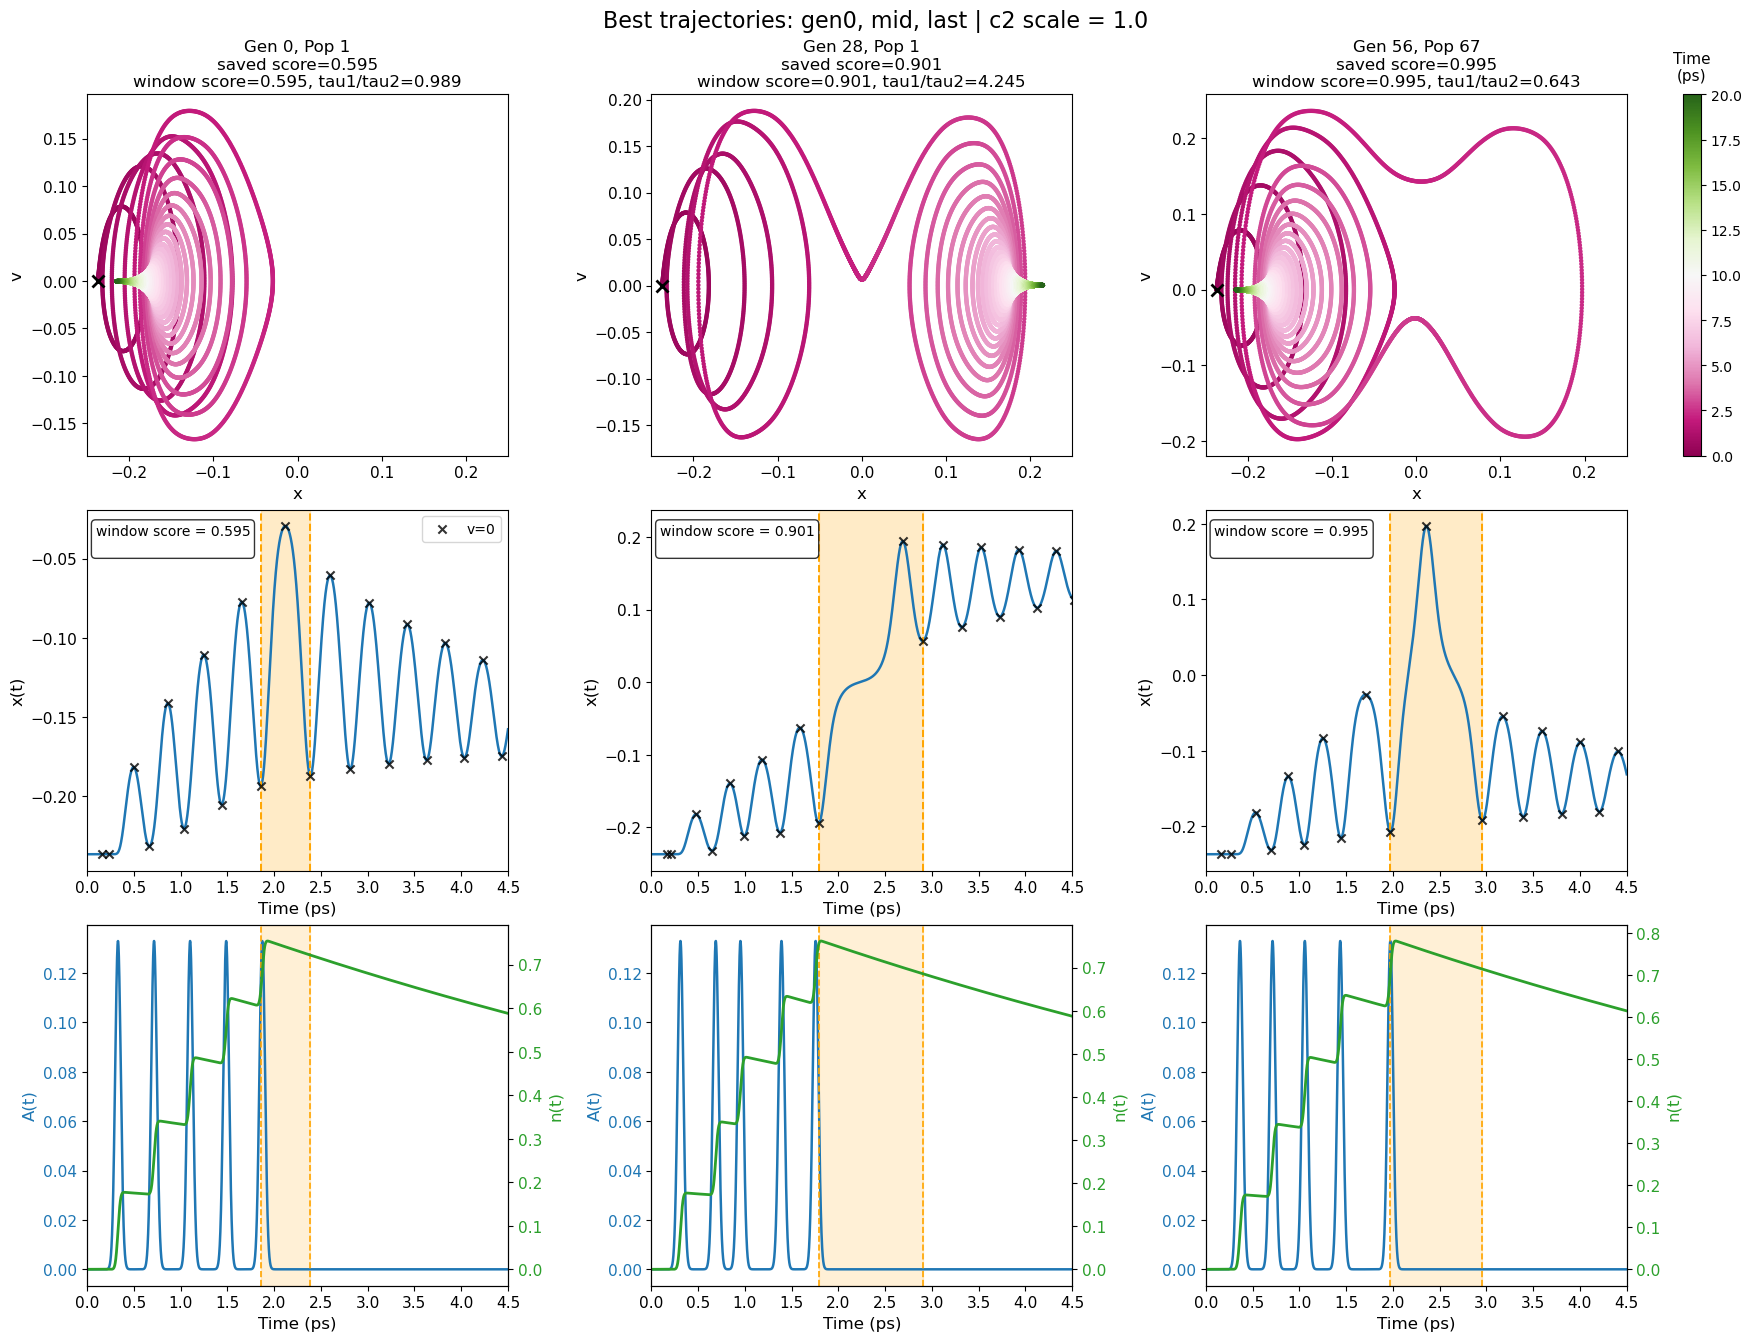

Saved: score_vs_generation_all_protocols_c2scale_1.0.png


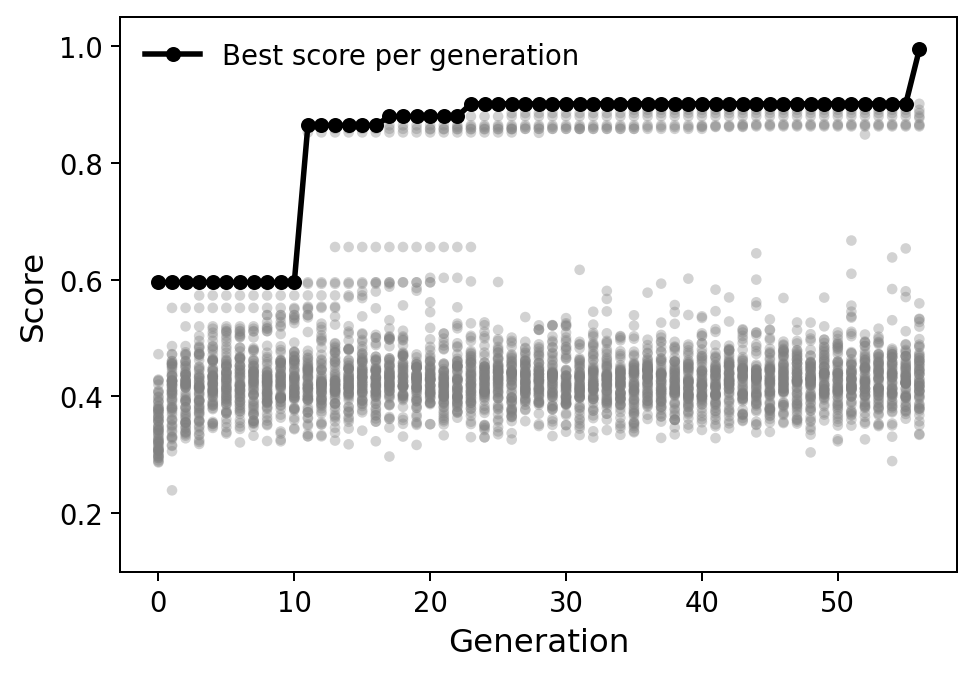

In [24]:
# ============================================================
# FOLLOW-UP PLOTTING CELL
# Uses new full pickle:
#   compact_full_all_pop_all_gen.pkl
#
# Plots best trajectory for:
#   gen0, mid gen, last gen
#
# rows = [phase space, x(t) with max-score window, protocol+n(t)]
# cols = [gen0, mid, last]
# ============================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ----------------------------
# load new full pickle
# ----------------------------
PKLFILE = "compact_full_all_pop_all_gen.pkl"

with open(PKLFILE, "rb") as f:
    all_results = pickle.load(f)

print("Available c2 scales:", list(all_results.keys()))

# ----------------------------
# fallbacks for globals
# ----------------------------
try:
    t_in_ps
except NameError:
    try:
        t_in_ps = TIME_UNIT_PS
    except NameError:
        t_in_ps = 1.0
        print("WARNING: t_in_ps not found, using 1.0")

try:
    x_scale
except NameError:
    try:
        x_scale = x_saddle
    except NameError:
        x_scale = 1.0
        print("WARNING: x_scale not found, using 1.0")

# ------------------------------------------------------------
# user controls
# ------------------------------------------------------------
xmax_ps = 4.5
save_figs = True
out_prefix = "best_gen0_mid_last_summary"
phase_scatter_size = 10
start_marker_size = 75
cross_marker_size = 35

def compute_score_window_debug(x_traj, v_traj, t_ps, x_scale):
    indices = []
    for m in range(1, len(v_traj)):
        if (v_traj[m] * v_traj[m - 1]) < 0:
            indices.append(m - 1)

    indices = np.array(indices, dtype=int)

    windows = []
    traj_avg = []
    tau_ratios = []

    for m in range(1, len(indices) - 2, 2):
        start_index = indices[m]
        end_index = indices[m + 2]

        if end_index >= len(x_traj):
            continue

        windows.append((start_index, end_index))

        segment = x_traj[start_index:end_index + 1]
        avg_val = np.mean(segment) if len(segment) > 0 else 0.0

        if avg_val <= 0:
            frac = 1 + (avg_val / x_scale)
        else:
            frac = 1 - (avg_val / x_scale)

        traj_avg.append(frac)

        cross1 = indices[m]
        cross2 = indices[m + 1]
        cross3 = indices[m + 2]

        tau1 = t_ps[cross2] - t_ps[cross1]
        tau2 = t_ps[cross3] - t_ps[cross2]
        tau_ratios.append(tau1 / tau2 if tau2 != 0 else np.nan)

    return (
        indices,
        windows,
        np.asarray(traj_avg, dtype=float),
        np.asarray(tau_ratios, dtype=float),
    )


def get_protocol_series(traj):
    candidate_keys = [
        "A", "A_t", "A_used", "A_t_used",
        "protocol", "protocol_used",
        "field", "field_used",
        "pulse", "pulse_used",
        "E_t", "E_used",
        "drive", "drive_used",
        "normA2_used",
        "all_nn_ifft",
    ]

    t_len = len(traj["t"])

    for key in candidate_keys:
        if key in traj:
            arr = np.asarray(traj[key]).squeeze()
            if arr.ndim == 1 and len(arr) == t_len:
                return arr, key

    return None, None


def make_best_score_text(payload, saved_best_score=None):
    traj_avg = payload["traj_avg"]
    tau_ratios = payload["tau_ratios"]

    if len(traj_avg) == 0:
        if saved_best_score is None:
            return "window score: N/A"
        return f"saved score={saved_best_score:.3f}\nwindow score: N/A"

    imax = int(np.argmax(traj_avg))
    score = traj_avg[imax]
    tau_ratio = tau_ratios[imax] if imax < len(tau_ratios) else np.nan

    if saved_best_score is None:
        return f"window score={score:.3f}, tau1/tau2={tau_ratio:.3f}"

    return (
        f"saved score={saved_best_score:.3f}\n"
        f"window score={score:.3f}, tau1/tau2={tau_ratio:.3f}"
    )


def select_gen0_mid_last(score_entries):
    n = len(score_entries)
    if n == 0:
        return []

    idxs = [0, n // 2, n - 1]

    # avoid duplicates for very short runs
    unique_idxs = []
    for i in idxs:
        if i not in unique_idxs:
            unique_idxs.append(i)

    return [score_entries[i] for i in unique_idxs]


# ============================================================
# main plotting loop
# ============================================================
for c2_scale, compact in all_results.items():

    score_entries = compact.get("score_vs_gen", [])

    if len(score_entries) == 0:
        print(f"No score_vs_gen found for c2_scale={c2_scale}")
        continue

    entries_to_plot = select_gen0_mid_last(score_entries)

    print(
        f"\nc2_scale={c2_scale}: plotting gens",
        [entry["gen"] for entry in entries_to_plot]
    )

    ncols = len(entries_to_plot)

    # ----------------------------
    # collect best trajs first
    # ----------------------------
    best_items = []
    global_tmin = np.inf
    global_tmax = -np.inf

    for entry in entries_to_plot:
        gen = int(entry["gen"])

        if "best_traj" in entry:
            best_traj = entry["best_traj"]
        elif "top3_traj" in entry:
            best_traj = entry["top3_traj"][0]
        elif "all_traj" in entry:
            best_traj = entry["all_traj"][int(entry["best_pop_idx"])]
        else:
            raise KeyError(
                f"Generation {gen} has no best_traj/top3_traj/all_traj. "
                "This pickle does not contain full trajectory data."
            )

        t_ps = np.asarray(best_traj["t"]) * t_in_ps
        x_traj = np.asarray(best_traj["x"])
        v_traj = np.asarray(best_traj["v"])

        indices, windows, traj_avg, tau_ratios = compute_score_window_debug(
            x_traj=x_traj,
            v_traj=v_traj,
            t_ps=t_ps,
            x_scale=x_scale,
        )

        payload = {
            "indices": indices,
            "windows": windows,
            "traj_avg": traj_avg,
            "tau_ratios": tau_ratios,
        }

        global_tmin = min(global_tmin, np.min(t_ps))
        global_tmax = max(global_tmax, np.max(t_ps))

        best_items.append({
            "gen": gen,
            "traj": best_traj,
            "payload": payload,
            "saved_best_score": float(entry["best_score"])
                if "best_score" in entry else None,
            "best_pop_idx": int(entry["best_pop_idx"])
                if "best_pop_idx" in entry else int(best_traj.get("pop_idx", -1)),
        })

    # ----------------------------
    # create figure
    # ----------------------------
    fig, axs = plt.subplots(
        3, ncols,
        figsize=(5.8 * ncols, 13.0),
        squeeze=False,
        constrained_layout=True,
    )

    norm_time = Normalize(vmin=global_tmin, vmax=global_tmax)
    sc_for_cbar = None

    # ----------------------------
    # plot each selected gen
    # ----------------------------
    for col, item in enumerate(best_items):

        gen = item["gen"]
        traj = item["traj"]
        payload = item["payload"]
        saved_best_score = item["saved_best_score"]

        pop_idx = int(traj.get("pop_idx", item["best_pop_idx"]))

        t_ps = np.asarray(traj["t"]) * t_in_ps
        x_traj = np.asarray(traj["x"])
        v_traj = np.asarray(traj["v"])
        n_traj = np.asarray(traj["n"]) if "n" in traj else None

        indices = payload["indices"]
        windows = payload["windows"]
        traj_avg = payload["traj_avg"]
        tau_ratio = payload["tau_ratios"]

        protocol_y, protocol_label = get_protocol_series(traj)

        # ====================================================
        # ROW 0: phase space
        # ====================================================
        ax = axs[0, col]

        sc_for_cbar = ax.scatter(
            x_traj,
            v_traj,
            c=t_ps,
            cmap="PiYG",
            norm=norm_time,
            s=phase_scatter_size,
            edgecolor="none",
        )

        ax.scatter(
            x_traj[0],
            v_traj[0],
            marker="x",
            s=start_marker_size,
            linewidths=2.0,
            color="k",
            zorder=5,
        )

        ax.set_title(
            f"Gen {gen}, Pop {pop_idx + 1}\n"
            f"{make_best_score_text(payload, saved_best_score)}",
            fontsize=12,
        )
        ax.set_xlabel("x", fontsize=12)
        ax.set_ylabel("v", fontsize=12)
        ax.set_xlim(-0.25, 0.25)
        ax.tick_params(labelsize=11)

        # ====================================================
        # ROW 1: x(t) with max score window
        # ====================================================
        ax = axs[1, col]

        ax.plot(t_ps, x_traj, color="tab:blue", linewidth=1.8)

        if len(indices) > 0:
            ax.scatter(
                t_ps[indices],
                x_traj[indices],
                marker="x",
                s=cross_marker_size,
                color="k",
                alpha=0.8,
                zorder=4,
                label="v=0",
            )

        if len(traj_avg) > 0:
            imax = int(np.argmax(traj_avg))
            i0, i1 = windows[imax]
            best_window_score = traj_avg[imax]
            best_tau = tau_ratio[imax] if imax < len(tau_ratio) else np.nan

            ax.axvspan(t_ps[i0], t_ps[i1], color="orange", alpha=0.22)
            ax.axvline(t_ps[i0], color="orange", linestyle="--", linewidth=1.4)
            ax.axvline(t_ps[i1], color="orange", linestyle="--", linewidth=1.4)

            ax.text(
                0.02,
                0.96,
                #f"saved score = {saved_best_score:.3f}\n"
                f"window score = {best_window_score:.3f}\n",
                #f"window = [{t_ps[i0]:.2f}, {t_ps[i1]:.2f}] ps\n"
                #f"tau1/tau2 = {best_tau:.3f}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=10,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
            )
        else:
            ax.text(
                0.02,
                0.96,
                "no valid score window",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=10,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
            )

        ax.set_xlim(0, xmax_ps)
        ax.set_xlabel("Time (ps)", fontsize=12)
        ax.set_ylabel("x(t)", fontsize=12)
        ax.tick_params(labelsize=11)

        if col == 0:
            ax.legend(fontsize=10, loc="best")

        # ====================================================
        # ROW 2: protocol with n(t) on twin axis
        # ====================================================
        ax = axs[2, col]
        ax2 = ax.twinx()

        line_handles = []
        line_labels = []

        if protocol_y is not None:
            l1 = ax.plot(
                t_ps,
                protocol_y,
                color="tab:blue",
                linewidth=1.8,
                label=protocol_label,
            )
            line_handles += l1
            line_labels += [protocol_label]
        else:
            ax.text(
                0.5,
                0.5,
                "No saved protocol array found",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
            )

        if n_traj is not None:
            l2 = ax2.plot(
                t_ps,
                n_traj,
                color="tab:green",
                linewidth=2.0,
                label="n(t)",
            )
            line_handles += l2
            line_labels += ["n(t)"]

        if len(traj_avg) > 0:
            imax = int(np.argmax(traj_avg))
            i0, i1 = windows[imax]
            ax.axvspan(t_ps[i0], t_ps[i1], color="orange", alpha=0.16)
            ax.axvline(t_ps[i0], color="orange", linestyle="--", linewidth=1.2)
            ax.axvline(t_ps[i1], color="orange", linestyle="--", linewidth=1.2)

        ax.set_xlim(0, xmax_ps)
        ax.set_xlabel("Time (ps)", fontsize=12)
        ax.set_ylabel(
            "A(t)",
            fontsize=12,
            color="tab:blue",
        )
        ax2.set_ylabel("n(t)", fontsize=12, color="tab:green")
        ax.tick_params(axis="y", labelcolor="tab:blue", labelsize=11)
        ax2.tick_params(axis="y", labelcolor="tab:green", labelsize=11)
        ax.tick_params(axis="x", labelsize=11)

        # if col == 0 and len(line_handles) > 0:
        #     ax.legend(line_handles, line_labels, fontsize=10, loc="best")

    # ----------------------------
    # row labels
    # ----------------------------
    # axs[0, 0].annotate(
    #     "Phase\nspace",
    #     xy=(-0.28, 0.5),
    #     xycoords="axes fraction",
    #     rotation=90,
    #     ha="center",
    #     va="center",
    #     fontsize=14,
    #     fontweight="bold",
    # )

    # axs[1, 0].annotate(
    #     "Trajectory\nwith max-score window",
    #     xy=(-0.28, 0.5),
    #     xycoords="axes fraction",
    #     rotation=90,
    #     ha="center",
    #     va="center",
    #     fontsize=14,
    #     fontweight="bold",
    # )

    # axs[2, 0].annotate(
    #     "Protocol + n(t)\n(twin y-axis)",
    #     xy=(-0.28, 0.5),
    #     xycoords="axes fraction",
    #     rotation=90,
    #     ha="center",
    #     va="center",
    #     fontsize=14,
    #     fontweight="bold",
    # )

    # ----------------------------
    # shared colorbar
    # ----------------------------
    cbar = fig.colorbar(
        sc_for_cbar,
        ax=axs[0, :],
        orientation="vertical",
        fraction=0.018,
        pad=0.001,
    )
    cbar.ax.set_title("Time\n(ps)", fontsize=11, pad=10)
    cbar.ax.tick_params(labelsize=10)

    fig.suptitle(
        f"Best trajectories: gen0, mid, last | c2 scale = {c2_scale}",
        fontsize=16,
        y=1.02,
    )

    if save_figs:
        fname = f"{out_prefix}_c2scale_{c2_scale}.png"
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"Saved: {fname}")

    plt.show()

# ============================================================
# FIGURE: Score vs generation for all protocols
# Gray scatter = all population scores
# Black -o line = best score per generation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

save_score_fig = True
score_out_prefix = "score_vs_generation_all_protocols"

for c2_scale, compact in all_results.items():

    score_entries = compact.get("score_vs_gen", [])
    if len(score_entries) == 0:
        print(f"No score_vs_gen found for c2_scale={c2_scale}")
        continue

    gens = np.array([entry["gen"] for entry in score_entries], dtype=int)
    best_scores = np.array([entry["best_score"] for entry in score_entries], dtype=float)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=180)

    # all protocol scores as gray scatter
    for entry in score_entries:
        gen = int(entry["gen"])
        scores = np.asarray(entry["all_scores"], dtype=float)

        ax.scatter(
            np.full_like(scores, gen, dtype=float),
            scores,
            color="gray",
            alpha=0.35,
            s=18,
            edgecolor="none",
        )

    # best score as black -o line
    ax.plot(
        gens,
        best_scores,
        "-o",
        color="black",
        linewidth=2.2,
        markersize=5,
        label="Best score per generation",
    )

    ax.set_xlabel("Generation", fontsize=13)
    ax.set_ylabel("Score", fontsize=13)
    # ax.set_title(
    #     f"Score vs generation for all protocols | c2 scale = {c2_scale}",
    #     fontsize=14,
    # )

    ax.set_ylim(0.1, 1.05)
    #ax.grid(True, alpha=0.25)
    ax.legend(fontsize=11, loc="best", frameon=False)
    ax.tick_params(labelsize=11)

    if save_score_fig:
        fname = f"{score_out_prefix}_c2scale_{c2_scale}.png"
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"Saved: {fname}")

    plt.show()

times_array, weights_array =  [0.32962123] 
 [3.00149501]
alpha:1.0

Rank 1 | Pop idx = 1 | Score = 0.998663
  Peak internal field amplitude = 1.329759e-01
  Peak physical field amplitude = 5.558603 MV/m
alpha:0.5

Rank 1 | Pop idx = 1 | Score = 0.894149
  Peak internal field amplitude = 1.329759e-01
  Peak physical field amplitude = 5.558603 MV/m
alpha:0.45

Rank 1 | Pop idx = 1 | Score = 0.983669
  Peak internal field amplitude = 1.329759e-01
  Peak physical field amplitude = 5.558603 MV/m
alpha:0.44

Rank 1 | Pop idx = 1 | Score = 0.455744
  Peak internal field amplitude = 1.329759e-01
  Peak physical field amplitude = 5.558603 MV/m
alpha:0.35

Rank 1 | Pop idx = 1 | Score = 0.333594
  Peak internal field amplitude = 1.329759e-01
  Peak physical field amplitude = 5.558603 MV/m
alpha:0.25

Rank 1 | Pop idx = 1 | Score = 0.223180
  Peak internal field amplitude = 1.329759e-01
  Peak physical field amplitude = 5.558603 MV/m
Runtime of the code block: 3.87 seconds


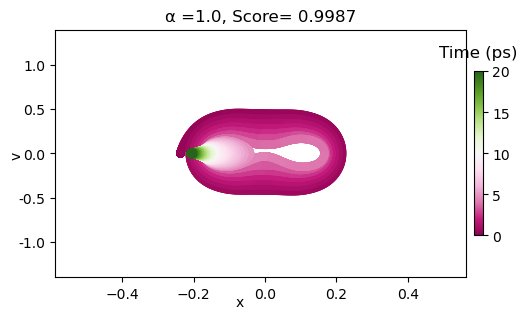

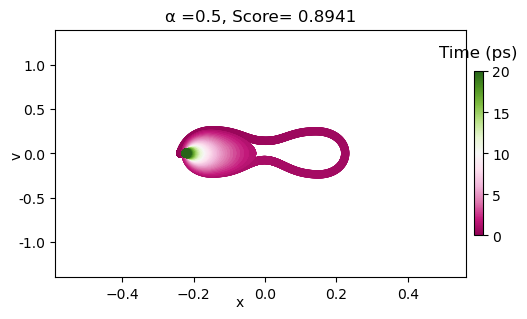

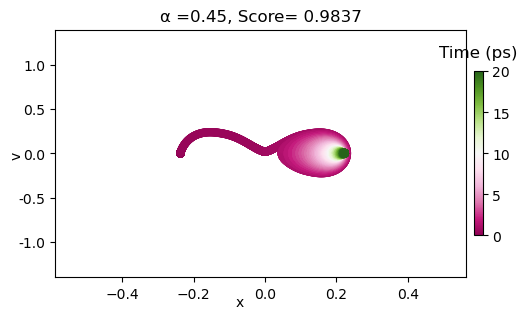

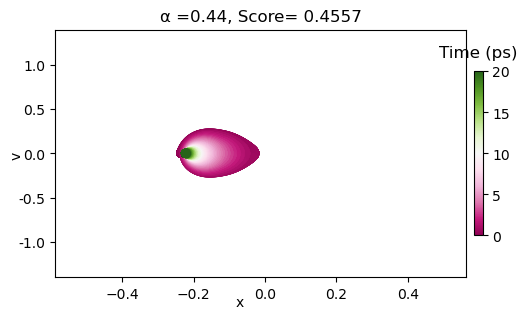

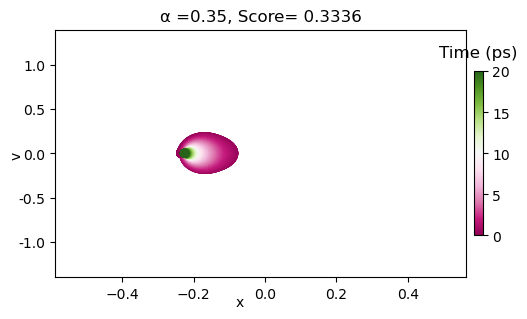

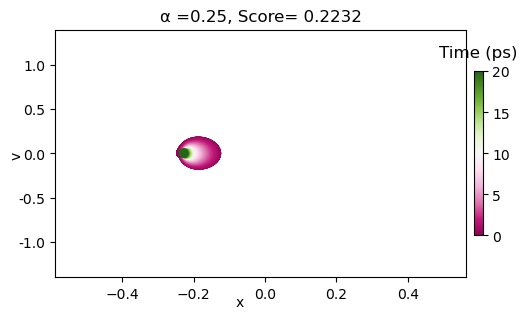

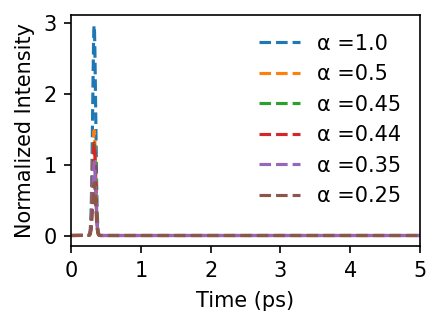

In [69]:
import time

#hidden_size=1
# def init_pop2(size, input_size, hidden_size, output_size, dt=1/bi_phfreq_in_thz):
#     population = []
#     fc1_wt = []  # List to store the fc1 weights separately
    
#     # Generate a list of weights arrays with proper starting value
#     for i in range(size):
#         increment =   0.20*dt * (i + 1)  # Increment increases with each population
#         times_array = np.array([dt + 0*j * increment for j in range(hidden_size)])
#         weights_array = 2*np.pi*(1/times_array)/freq_in_thz
#         weights_tensor = torch.tensor(weights_array, dtype=torch.float).view(hidden_size, input_size)
#         #if i ==size-1:
#            # print("times_array, weights_array = ",times_array, "\n", weights_array)
#         model = TestFNN_ex2(input_size, hidden_size, output_size, weights_array)
#         population.append(model)
#         fc1_wt.append(weights_tensor)  # Store the numpy array directly

#     return population, fc1_wt

hidden_size=1
def init_pop2(size, input_size, hidden_size, output_size, dt=1/bi_phfreq_in_thz):
    population = []
    fc1_wt = []  # List to store the fc1 weights separately
    
    # Generate a list of weights arrays with proper starting value
    for i in range(size):
        increment =   0.13*dt * (i + 9)  # Increment increases with each population
        times_array = np.array([dt + j * increment for j in range(hidden_size)])
        weights_array = 2*np.pi*(1/times_array)/freq_in_thz
        weights_tensor = torch.tensor(weights_array, dtype=torch.float).view(hidden_size, input_size)
        if i==0:
            print("times_array, weights_array = ",times_array, "\n", weights_array)
        model = TestFNN_ex2(input_size, hidden_size, output_size, weights_array)
        population.append(model)
        fc1_wt.append(weights_tensor)  # Store the numpy array directly

    return population, fc1_wt

n_pop=1
# Initialize population
pop_s1, pop_fc1_wt_s1 = init_pop2(n_pop, input_size, hidden_size, output_size, dt=1/bi_phfreq_in_thz)

start_time = time.time()
#num_parent = n_pop//10
#pop, pop_fc1_wt = init_pop(n_pop, input_size, hidden_size, output_size)
n_gen=1
select_gen=[0]
w1 = pop_fc1_wt_s1
b1 = np.full(hidden_size, const_b1)
w2 = np.full(hidden_size, const_w2)

def theor_fft(w1, b1, w2):
    results = []
    for weights in w1:
        weights = weights.detach().numpy()
        M_f_nn = np.sum(
            [w2[n] * np.exp(-1j * 2 * np.pi * fft_freqs * (2 * np.pi / (freq_in_thz * weights[n])) + b1[n])
             for n in range(len(weights))], axis=0
        )
        S_f_nn = G_f * M_f_nn
        ifft_nn = np.fft.ifft(S_f_nn)
        results.append(ifft_nn)
    return results


def run_generations(pop, pop_fc1_wt, t_eval, pulse_area_scale):
    current_pop = pop_s1
    current_fc1_wt = pop_fc1_wt_s1
    # Calculate the number of plots needed
    num_plots1 = len(select_gen)
    num_plots2 = 1
    print(f'alpha:{pulse_area_scale}')
    
    fig2, axs2 = plt.subplots(figsize=(5, 3 * num_plots1), squeeze=False, constrained_layout=True)
    
    norm = Normalize(vmin=1, vmax=n_pop)
    norm2 = Normalize(vmin=np.min(t_eval*t_in_ps), vmax=np.max(t_eval*t_in_ps))
    cmap = plt.cm.viridis
    reversed_cmap = cmap.reversed()
    sm = plt.cm.ScalarMappable(cmap=reversed_cmap, norm=norm)
    sm.set_array(np.linspace(1, n_pop, num=256))

    plot_idx = 0  # Index to track which subplot to use
    best_scores=[]
    best_score=0

    for gen in range(n_gen):
    #while (best_score <= 0.995):
        all_x = []
        all_v = []
        all_times = []
        all_nn_ifft = []
        results = theor_fft(current_fc1_wt, b1, w2)
        for idx, (ifft) in enumerate(results):
            
            ifft_norm = simpson(ifft.real**2,  x=t_eval.squeeze())
            # field amplitude metrics from raw protocol
            field_metrics = compute_field_amplitude_metrics(ifft)

            sol, debug_terms = simulate(
                nn_model_ifft=ifft,
                ifft_norm=ifft_norm,
                c2_int=c2_int_default,
                pes_interpolant=U,
                eps1_func=poly_model,
                eps2_func=poly_model_im,
                mode_mass=bi_mass,
                x0=bi_xmin,
                v0=0.0,
                n0=0.0,
                f_excited=0.5,
                pulse_area_scale=pulse_area_scale,
                beta_tau_ps=beta_paper,
                gamma_tau_ps=2.41,
                use_previous_gamma_convention=False,
                t_eval=t_eval,
                tfine=tfine,
                tspan=tspan,
            )
         
            all_times.append(sol.t)
            all_x.append(sol.y[0]) 
            all_v.append(sol.y[1])
            all_nn_ifft.append(ifft.real)

        ## --------------------------- Score3 function --------------------------------------------     
        score_val, _, bad_indices = score3(all_v, all_x)
        ## -----------------------------------------------------------------------   
        
        sorted_indices = np.argsort(score_val)[::-1]  # Indices of models from best to worst
        rank_positions = np.argsort(sorted_indices) 
        colors_score = [reversed_cmap(norm(rank)) for rank in rank_positions]
        colors = [cmap(norm(rank)) for rank in rank_positions]
        best_score = score_val[sorted_indices[0]]
        
        print_field_metrics_for_rank(
            rank=1,
            idx_top=1,
            score_top=best_score,
            field_metrics=field_metrics,
        )
           
        if gen in select_gen:
            count_axs2=0
            
            for idx in sorted_indices:
 
                # Plot top 3 protocols and phase space
                if idx in sorted_indices[:1]:
                    ax_ph = axs2[plot_idx, count_axs2]
                    sc=ax_ph.scatter(all_x[idx], all_v[idx], c = all_times[idx]*t_in_ps, cmap='PiYG', edgecolor='none', norm=norm2)
                    ax_ph.set_title(f'α ={pulse_area_scale}, Score= {best_score:.4f}')
                    ax_ph.yaxis.set_major_formatter(FormatStrFormatter('%.1f')) 
                    ax_ph.set_xlim(-0.35-x_saddle,0.8-x_saddle)
                    ax_ph.set_ylim(-1.4,1.4)

                    norm_fac = simpson(all_nn_ifft[idx]**2,  x=t_eval.squeeze())
                    
                    count_axs2+=1

            plot_idx += 1  

    fig2.text(0.45, 0.01, 'x', ha='center', va='center')
    fig2.text(0.005, 0.50, 'v', ha='center', va='center', rotation='vertical')
    cbar = fig2.colorbar(sc, ax=axs2, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.ax.set_title('Time (ps)', pad=10)

    return ifft, ifft_norm

vert_offset = np.linspace(0, 2*n_pop, n_pop)
alphas=[1.0, 0.5, 0.45, 0.44, 0.35, 0.25]

for i in range(len(alphas)):
    ifft_pl, ifft_norm_pl=run_generations(pop, pop_fc1_wt, t_eval, pulse_area_scale=alphas[i])

fig,ax=plt.subplots( figsize=(3, 2), dpi=150, facecolor='white')

for i in range(len(alphas)):
    #plt.plot(tfine*t_in_ps, (np.sqrt(alphas[i])*ifft_pl.real)/np.sqrt(ifft_norm_pl), linestyle = '--', label=f'α ={alphas[i]}')
    plt.plot(tfine*t_in_ps, (alphas[i]*((ifft_pl.real)**2))/ifft_norm_pl, linestyle = '--', label=f'α ={alphas[i]}')
    ax.set_xlabel("Time (ps)", labelpad=5)
    ax.set_ylabel("Normalized Intensity")  
    ax.set_xlim(0,5)
    ax.legend(frameon=False)

end_time = time.time()
runtime = end_time - start_time
print(f"Runtime of the code block: {runtime:.2f} seconds")

rho_shape(bi_xmin) = 1.326758541454993
rho_shape(x_saddle) = 0.5610232190535103
ratio saddle/equilibrium = 0.4228525398738061
-0.23686869232657531 0.0
relative variation of n2      = 1.2840014416302756
relative variation of R       = 0.8181830636946258
relative variation of rho     = 1.2299717144862028


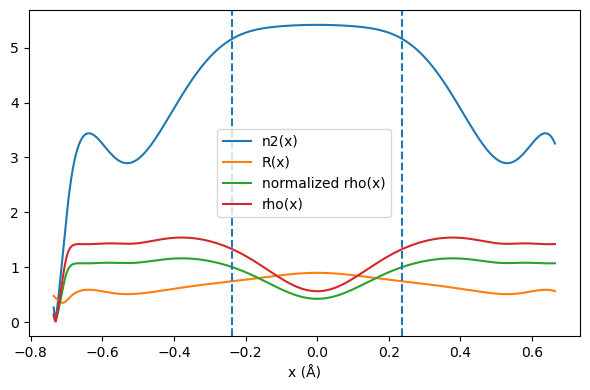

In [21]:
rho_eq = rho_shape_from_x(bi_xmin, poly_model, poly_model_im)
rho_sad = rho_shape_from_x(bi_xmax, poly_model, poly_model_im)

print("rho_shape(bi_xmin) =", rho_eq)
print("rho_shape(x_saddle) =", rho_sad)
print("ratio saddle/equilibrium =", rho_sad / rho_eq)

print(bi_xmin, bi_xmax)? 

xplot = xfine

eps1 = poly_model(xplot)
eps2 = poly_model_im(xplot)

rad = np.sqrt(eps1**2 + eps2**2)
n1 = np.sqrt(np.maximum(0.5 * (rad + eps1), 0.0))
n2 = np.sqrt(np.maximum(0.5 * (rad - eps1), 0.0))
R  = ((n1 - 1.0)**2 + n2**2) / ((n1 + 1.0)**2 + n2**2)

rho_shape = n2 * (1.0 - R)

print("relative variation of n2      =", (np.max(n2) - np.min(n2)) / np.mean(n2))
print("relative variation of R       =", (np.max(R)  - np.min(R))  / np.mean(R))
print("relative variation of rho     =", (np.max(rho_shape) - np.min(rho_shape)) / np.mean(rho_shape))

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(xplot, n2, label="n2(x)")
plt.plot(xplot, R, label="R(x)")
plt.plot(xplot, rho_shape / rho_shape_from_x(bi_xmin, poly_model, poly_model_im), label="normalized rho(x)")
plt.plot(xplot, rho_shape, label="rho(x)")
plt.axvline(bi_xmin, ls="--")
plt.axvline(x_saddle, ls="--")
plt.xlabel("x (Å)")
plt.legend()
plt.tight_layout()
plt.show()